In [1]:
import pandas as pd

events = pd.read_csv("../data/raw/events.csv")

print(events.shape)
print(events.head())
print(events.info())

(2756101, 5)
       timestamp  visitorid event  itemid  transactionid
0  1433221332117     257597  view  355908            NaN
1  1433224214164     992329  view  248676            NaN
2  1433221999827     111016  view  318965            NaN
3  1433221955914     483717  view  253185            NaN
4  1433221337106     951259  view  367447            NaN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB
None


In [2]:
events.describe(include="all")

,timestamp,visitorid,event,itemid,transactionid
count,2.756101e+06,2.756101e+06,2756101,2.756101e+06,22457.000000
unique,NaN,NaN,3,NaN,NaN
top,NaN,NaN,view,NaN,NaN
freq,NaN,NaN,2664312,NaN,NaN
mean,1.436424e+12,7.019229e+05,NaN,2.349225e+05,8826.497796
std,3.366312e+09,4.056875e+05,NaN,1.341954e+05,5098.996290
min,1.430622e+12,0.000000e+00,NaN,3.000000e+00,0.000000
25%,1.433478e+12,3.505660e+05,NaN,1.181200e+05,4411.000000
50%,1.436453e+12,7.020600e+05,NaN,2.360670e+05,8813.000000
75%,1.439225e+12,1.053437e+06,NaN,3.507150e+05,13224.000000


In [3]:
events["event"].value_counts()

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

In [4]:
events = events.rename(columns={
    "visitorid": "user_id",
    "itemid": "item_id"
})

In [5]:
events["timestamp"] = pd.to_datetime(
    events["timestamp"],
    unit="ms"
)

In [6]:
print(events["timestamp"].min())
print(events["timestamp"].max())

2015-05-03 03:00:04.384000
2015-09-18 02:59:47.788000


In [7]:
print("Exact duplicates:", events.duplicated().sum())

Exact duplicates: 460


In [8]:
interaction_weights = {
    "view": 1,
    "addtocart": 3,
    "transaction": 5
}

events["interaction_strength"] = events["event"].map(
    interaction_weights
)

In [9]:
interactions = events[
    [
        "user_id",
        "item_id",
        "event",
        "timestamp",
        "interaction_strength"
    ]
].copy()

In [10]:
interactions.head()

,user_id,item_id,event,timestamp,interaction_strength
0,257597,355908,view,2015-06-02 05:02:12.117,1
1,992329,248676,view,2015-06-02 05:50:14.164,1
2,111016,318965,view,2015-06-02 05:13:19.827,1
3,483717,253185,view,2015-06-02 05:12:35.914,1
4,951259,367447,view,2015-06-02 05:02:17.106,1


In [11]:
interactions.to_parquet(
    "../data/processed/interactions.parquet",
    index=False
)

<Axes: xlabel='timestamp'>

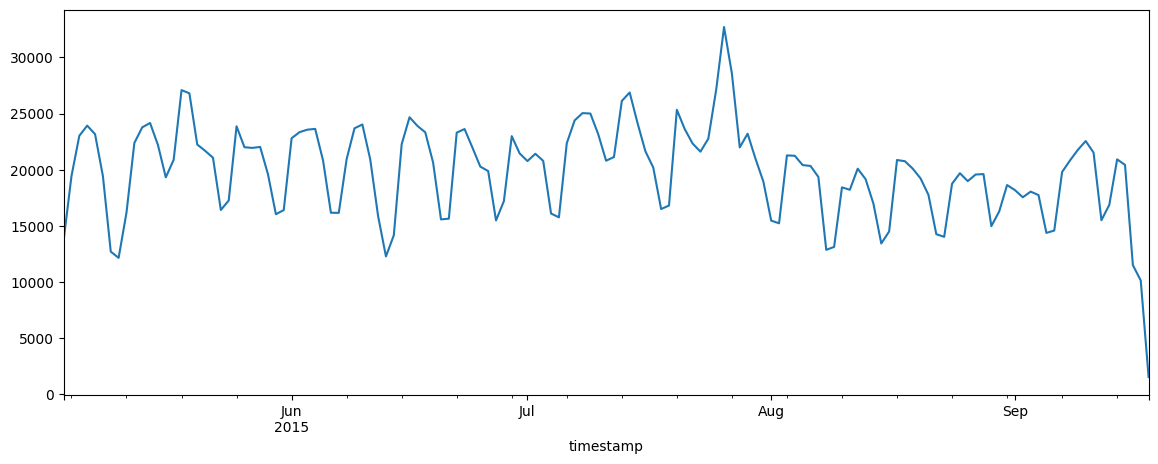

In [12]:
daily_events = (
    interactions
    .set_index("timestamp")
    .resample("D")
    .size()
)

daily_events.plot(figsize=(14, 5))

In [14]:
print(events.shape)
print(events.head())
print(events.info())
print(events["event"].value_counts())
print("Duplicates:", events.duplicated().sum())

(2756101, 6)
                timestamp  user_id event  item_id  transactionid  \
0 2015-06-02 05:02:12.117   257597  view   355908            NaN   
1 2015-06-02 05:50:14.164   992329  view   248676            NaN   
2 2015-06-02 05:13:19.827   111016  view   318965            NaN   
3 2015-06-02 05:12:35.914   483717  view   253185            NaN   
4 2015-06-02 05:02:17.106   951259  view   367447            NaN   

   interaction_strength  
0                     1  
1                     1  
2                     1  
3                     1  
4                     1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 6 columns):
 #   Column                Dtype         
---  ------                -----         
 0   timestamp             datetime64[ns]
 1   user_id               int64         
 2   event                 object        
 3   item_id               int64         
 4   transactionid         float64       
 5   interaction

In [15]:
print("Rows before:", len(interactions))

interactions = interactions.drop_duplicates().reset_index(drop=True)

print("Rows after:", len(interactions))
print("Removed:", 2756101 - len(interactions))

Rows before: 2756101
Rows after: 2755641
Removed: 460


In [16]:
print(interactions.isna().sum())

user_id                 0
item_id                 0
event                   0
timestamp               0
interaction_strength    0
dtype: int64


In [17]:
print(interactions["interaction_strength"].isna().sum())

0


In [18]:
print(interactions["event"].unique())

['view' 'addtocart' 'transaction']


In [19]:
print("Min timestamp:", interactions["timestamp"].min())
print("Max timestamp:", interactions["timestamp"].max())

Min timestamp: 2015-05-03 03:00:04.384000
Max timestamp: 2015-09-18 02:59:47.788000


In [20]:
print(
    interactions["timestamp"]
    .is_monotonic_increasing
)

False


In [21]:
interactions = interactions.sort_values("timestamp")

In [23]:
interactions = interactions.drop_duplicates().reset_index(drop=True)

print("Rows:", len(interactions))
print("\nMissing values:")
print(interactions.isna().sum())

print("\nEvents:")
print(interactions["event"].value_counts())

print("\nUnique events:")
print(interactions["event"].unique())

print("\nTimestamp range:")
print(interactions["timestamp"].min())
print(interactions["timestamp"].max())

print("\nInvalid interaction strengths:")
print(interactions["interaction_strength"].isna().sum())

Rows: 2755641

Missing values:
user_id                 0
item_id                 0
event                   0
timestamp               0
interaction_strength    0
dtype: int64

Events:
event
view           2664218
addtocart        68966
transaction      22457
Name: count, dtype: int64

Unique events:
['addtocart' 'view' 'transaction']

Timestamp range:
2015-05-03 03:00:04.384000
2015-09-18 02:59:47.788000

Invalid interaction strengths:
0


In [24]:
daily_events = (
    interactions
    .set_index("timestamp")
    .resample("D")
    .size()
)

print(daily_events)

timestamp
2015-05-03    13682
2015-05-04    19413
2015-05-05    23011
2015-05-06    23920
2015-05-07    23157
              ...  
2015-09-14    20905
2015-09-15    20425
2015-09-16    11494
2015-09-17    10126
2015-09-18     1528
Freq: D, Length: 139, dtype: int64


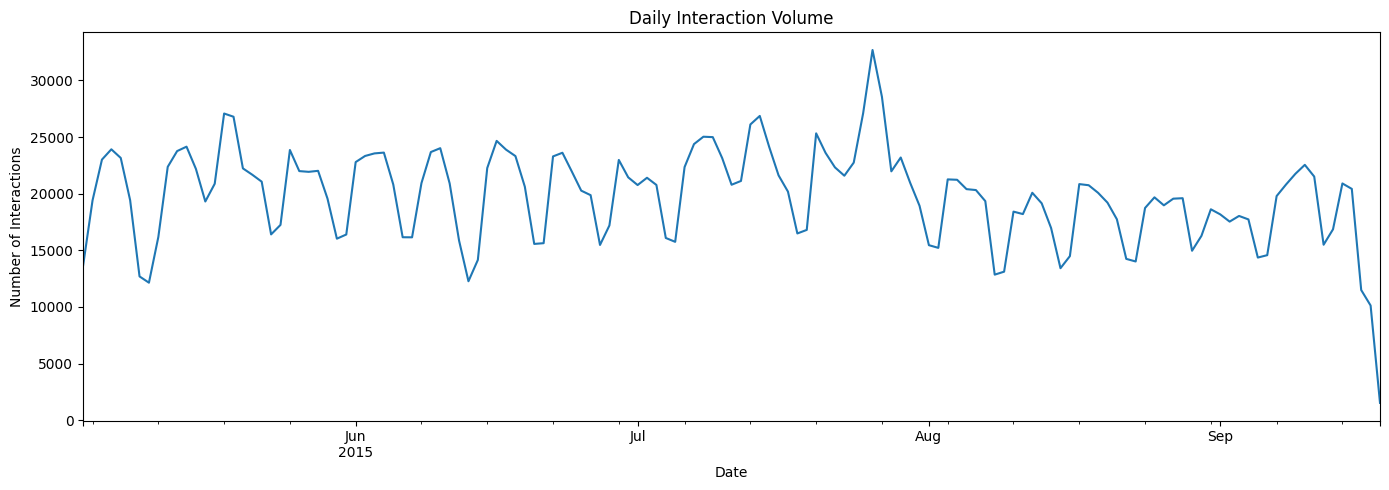

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
daily_events.plot()
plt.title("Daily Interaction Volume")
plt.xlabel("Date")
plt.ylabel("Number of Interactions")
plt.tight_layout()
plt.show()

In [26]:
print("Number of days:", len(daily_events))
print("Mean daily interactions:", daily_events.mean())
print("Median daily interactions:", daily_events.median())
print("Minimum:", daily_events.min())
print("Maximum:", daily_events.max())

Number of days: 139
Mean daily interactions: 19824.755395683453
Median daily interactions: 20619.0
Minimum: 1528
Maximum: 32692


In [27]:
weekly_events = (
    interactions
    .set_index("timestamp")
    .resample("W")
    .size()
)

print(weekly_events)

timestamp
2015-05-03     13682
2015-05-10    133760
2015-05-17    148840
2015-05-24    152500
2015-05-31    141802
2015-06-07    146426
2015-06-14    131827
2015-06-21    145957
2015-06-28    141677
2015-07-05    139211
2015-07-12    161825
2015-07-19    152214
2015-07-26    175392
2015-08-02    144304
2015-08-09    128529
2015-08-16    120730
2015-08-23    126889
2015-08-30    127794
2015-09-06    119031
2015-09-13    138773
2015-09-20     64478
Freq: W-SUN, dtype: int64


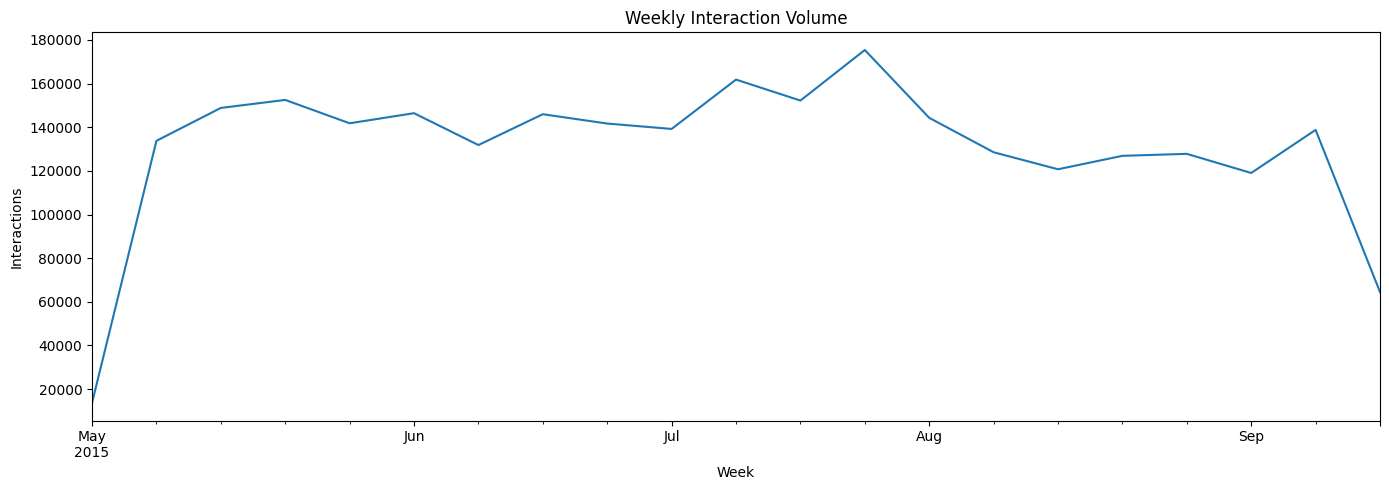

In [28]:
plt.figure(figsize=(14, 5))
weekly_events.plot()
plt.title("Weekly Interaction Volume")
plt.xlabel("Week")
plt.ylabel("Interactions")
plt.tight_layout()
plt.show()

In [29]:
print(
    "Unique users:",
    interactions["user_id"].nunique()
)

print(
    "Unique items:",
    interactions["item_id"].nunique()
)

Unique users: 1407580
Unique items: 235061


In [30]:
train_cutoff = interactions["timestamp"].quantile(0.70)
val_cutoff = interactions["timestamp"].quantile(0.85)

print("Train cutoff:", train_cutoff)
print("Validation cutoff:", val_cutoff)

Train cutoff: 2015-08-02 23:29:03.291000064
Validation cutoff: 2015-08-25 22:31:01.628999936


In [31]:
train = interactions[
    interactions["timestamp"] < train_cutoff
].copy()

validation = interactions[
    (interactions["timestamp"] >= train_cutoff) &
    (interactions["timestamp"] < val_cutoff)
].copy()

test = interactions[
    interactions["timestamp"] >= val_cutoff
].copy()

In [32]:
print("TRAIN")
print("Rows:", len(train))
print("Min:", train["timestamp"].min())
print("Max:", train["timestamp"].max())

print("\nVALIDATION")
print("Rows:", len(validation))
print("Min:", validation["timestamp"].min())
print("Max:", validation["timestamp"].max())

print("\nTEST")
print("Rows:", len(test))
print("Min:", test["timestamp"].min())
print("Max:", test["timestamp"].max())

TRAIN
Rows: 1928949
Min: 2015-05-03 03:00:04.384000
Max: 2015-08-02 23:29:03.291000

VALIDATION
Rows: 413345
Min: 2015-08-02 23:29:05.026000
Max: 2015-08-25 22:30:59.619000

TEST
Rows: 413347
Min: 2015-08-25 22:31:01.629000
Max: 2015-09-18 02:59:47.788000


In [33]:
print("\nPercentages:")

total = len(interactions)

print("Train:", len(train) / total * 100)
print("Validation:", len(validation) / total * 100)
print("Test:", len(test) / total * 100)


Percentages:
Train: 70.0000108867592
Validation: 14.999958267423077
Test: 15.000030845817724


In [34]:
print(
    "Train ends:",
    train["timestamp"].max()
)

print(
    "Validation starts:",
    validation["timestamp"].min()
)

print(
    "Validation ends:",
    validation["timestamp"].max()
)

print(
    "Test starts:",
    test["timestamp"].min()
)

Train ends: 2015-08-02 23:29:03.291000
Validation starts: 2015-08-02 23:29:05.026000
Validation ends: 2015-08-25 22:30:59.619000
Test starts: 2015-08-25 22:31:01.629000


In [36]:
assert train["timestamp"].max() < validation["timestamp"].min()
assert validation["timestamp"].max() < test["timestamp"].min()

print("No temporal leakage")

No temporal leakage


In [37]:
train.to_parquet(
    "../data/processed/train.parquet",
    index=False
)

validation.to_parquet(
    "../data/processed/validation.parquet",
    index=False
)

test.to_parquet(
    "../data/processed/test.parquet",
    index=False
)

In [38]:
train_users = set(train["user_id"].unique())
train_items = set(train["item_id"].unique())

In [39]:
val_users = set(validation["user_id"].unique())
val_items = set(validation["item_id"].unique())

test_users = set(test["user_id"].unique())
test_items = set(test["item_id"].unique())

In [41]:
warm_val_users = val_users & train_users
cold_val_users = val_users - train_users

warm_test_users = test_users & train_users
cold_test_users = test_users - train_users

In [42]:
print("VALIDATION USERS")
print("Total:", len(val_users))
print("Warm:", len(warm_val_users))
print("Cold:", len(cold_val_users))

print("\nTEST USERS")
print("Total:", len(test_users))
print("Warm:", len(warm_test_users))
print("Cold:", len(cold_test_users))

VALIDATION USERS
Total: 234715
Warm: 18965
Cold: 215750

TEST USERS
Total: 233728
Warm: 13840
Cold: 219888


In [43]:
warm_val_items = val_items & train_items
cold_val_items = val_items - train_items

warm_test_items = test_items & train_items
cold_test_items = test_items - train_items

In [44]:
print("\nVALIDATION ITEMS")
print("Total:", len(val_items))
print("Warm:", len(warm_val_items))
print("Cold:", len(cold_val_items))

print("\nTEST ITEMS")
print("Total:", len(test_items))
print("Warm:", len(warm_test_items))
print("Cold:", len(cold_test_items))


VALIDATION ITEMS
Total: 97621
Warm: 80002
Cold: 17619

TEST ITEMS
Total: 97581
Warm: 77182
Cold: 20399


In [45]:
print("\n--- USER COLD START ---")

print(
    "Validation cold-user %:",
    len(cold_val_users) / len(val_users) * 100
)

print(
    "Test cold-user %:",
    len(cold_test_users) / len(test_users) * 100
)

print("\n--- ITEM COLD START ---")

print(
    "Validation cold-item %:",
    len(cold_val_items) / len(val_items) * 100
)

print(
    "Test cold-item %:",
    len(cold_test_items) / len(test_items) * 100
)


--- USER COLD START ---
Validation cold-user %: 91.91998807063885
Test cold-user %: 94.07858707557503

--- ITEM COLD START ---
Validation cold-item %: 18.048370739902275
Test cold-item %: 20.904684313544646


In [46]:
for name, df in [
    ("TRAIN", train),
    ("VALIDATION", validation),
    ("TEST", test)
]:
    print(f"\n{name}")
    print(df["event"].value_counts())
    print(
        (df["event"].value_counts(normalize=True) * 100)
        .round(2)
    )


TRAIN
event
view           1865997
addtocart        47315
transaction      15637
Name: count, dtype: int64
event
view           96.74
addtocart       2.45
transaction     0.81
Name: proportion, dtype: float64

VALIDATION
event
view           398920
addtocart       10956
transaction      3469
Name: count, dtype: int64
event
view           96.51
addtocart       2.65
transaction     0.84
Name: proportion, dtype: float64

TEST
event
view           399301
addtocart       10695
transaction      3351
Name: count, dtype: int64
event
view           96.60
addtocart       2.59
transaction     0.81
Name: proportion, dtype: float64
